# **Results Comparison**

In [1]:
print("Results loaded successfully.")

Results loaded successfully.


In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
folder_path = r'C:\Users\Ale\Documents\Lab01\model_metrics'    

In [10]:
def open_json(folder_path):
    all_data = []
    for file in os.listdir(folder_path):
        if file.endswith('.json'):
            with open(os.path.join(folder_path, file), 'r') as f:
                data = json.load(f)
                all_data.append(data)
    
    return all_data

metrics = open_json(folder_path)
print(metrics)


[{'model': '1. MLP', 'representation': 'Time Domain', 'accuracy': 0.6896551724137931, 'precision': 0.52, 'recall': 0.4642857142857143, 'f1_score': 0.49056603773584906, 'auc': 0.6355932950973511, 'timestamp': '2026-02-14 20:27:48'}, {'model': '2. MLP', 'representation': 'Frequency Domain', 'accuracy': 0.896551724137931, 'precision': 0.9523809523809523, 'recall': 0.7142857142857143, 'f1_score': 0.8163265306122449, 'auc': 0.8435229659080505, 'timestamp': '2026-02-14 20:29:28'}, {'model': '3. MLP', 'representation': 'Spectogram', 'accuracy': 0.8620689655172413, 'precision': 1.0, 'recall': 0.5714285714285714, 'f1_score': 0.7272727272727273, 'auc': 0.7857142686843872, 'timestamp': '2026-02-14 20:30:13'}, {'model': '4. MLP', 'representation': 'Mel Spectogram', 'accuracy': 0.7701149425287356, 'precision': 0.6, 'recall': 0.8571428571428571, 'f1_score': 0.7058823529411765, 'auc': 0.8526029586791992, 'timestamp': '2026-02-14 20:42:44'}, {'model': '5. MLP', 'representation': 'Mel Coef Spectogram',

In [11]:
df = pd.DataFrame(metrics)

In [12]:
df.head()

,model,representation,accuracy,precision,recall,f1_score,auc,timestamp
0,1. MLP,Time Domain,0.689655,0.520000,0.464286,0.490566,0.635593,2026-02-14 20:27:48
1,2. MLP,Frequency Domain,0.896552,0.952381,0.714286,0.816327,0.843523,2026-02-14 20:29:28
2,3. MLP,Spectogram,0.862069,1.000000,0.571429,0.727273,0.785714,2026-02-14 20:30:13
3,4. MLP,Mel Spectogram,0.770115,0.600000,0.857143,0.705882,0.852603,2026-02-14 20:42:44
4,5. MLP,Mel Coef Spectogram,0.839080,0.850000,0.607143,0.708333,0.810533,2026-02-14 20:36:35


Comparison Graphs

In [15]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "auc"]

df_long = df.melt(
    id_vars="representation",
    value_vars=metrics_to_plot,
    var_name="metric",
    value_name="value"
)

print(df_long.head())

        representation    metric     value
0          Time Domain  accuracy  0.689655
1     Frequency Domain  accuracy  0.896552
2           Spectogram  accuracy  0.862069
3       Mel Spectogram  accuracy  0.770115
4  Mel Coef Spectogram  accuracy  0.839080


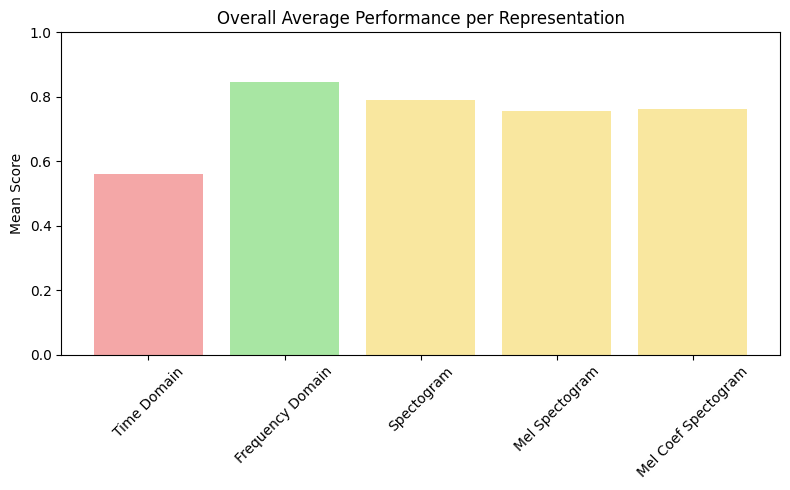

In [ ]:


# Compute mean score
df["mean_score"] = df[["accuracy","precision","recall","f1_score","auc"]].mean(axis=1)

# Identify max and min
max_value = df["mean_score"].max()
min_value = df["mean_score"].min()

# Pastel color palette
pastel_green = "#A8E6A3"
pastel_red = "#F4A7A7"
pastel_yellow = "#F9E79F"

# Assign colors
colors = []

for value in df["mean_score"]:
    if value == max_value:
        colors.append(pastel_green)
    elif value == min_value:
        colors.append(pastel_red)
    else:
        colors.append(pastel_yellow)

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(df["representation"], df["mean_score"], color=colors)

plt.xticks(rotation=45)
plt.ylim(0,1)
plt.ylabel("Mean Score")
plt.title("Overall Average Performance per Representation")

plt.tight_layout()
plt.show()

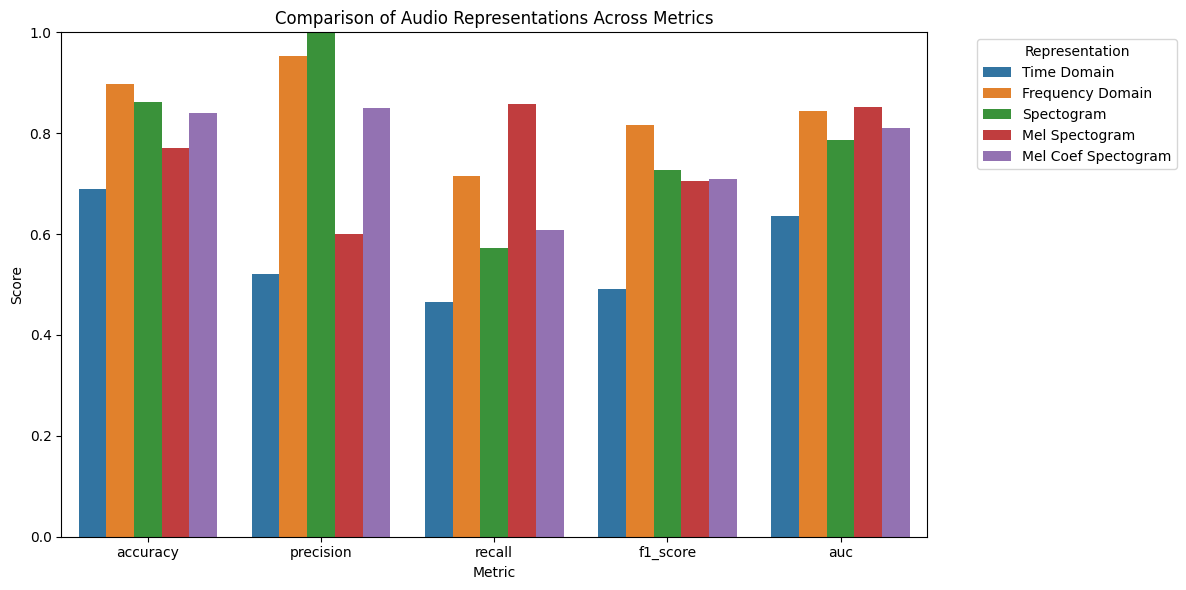

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_long,
    x="metric",
    y="value",
    hue="representation"
)

plt.title("Comparison of Audio Representations Across Metrics")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.legend(title="Representation", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

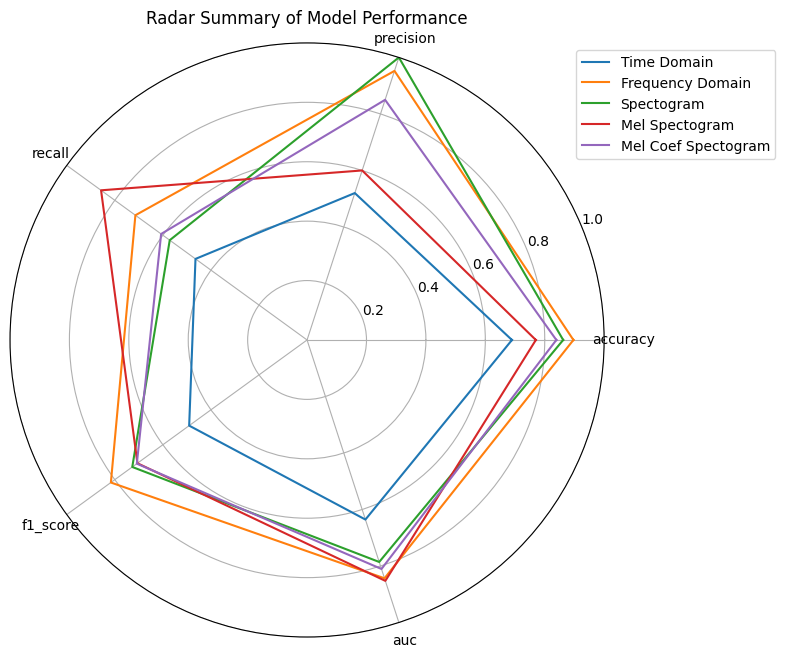

In [ ]:


metrics = ["accuracy", "precision", "recall", "f1_score", "auc"]
labels = metrics
num_metrics = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8, 8))

for i in range(len(df)):
    values = df.loc[i, metrics].tolist()
    values += values[:1]
    
    plt.polar(angles, values, label=df.loc[i, "representation"])

plt.xticks(angles[:-1], labels)
plt.ylim(0, 1)
plt.title("Radar Summary of Model Performance")
plt.legend(bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()

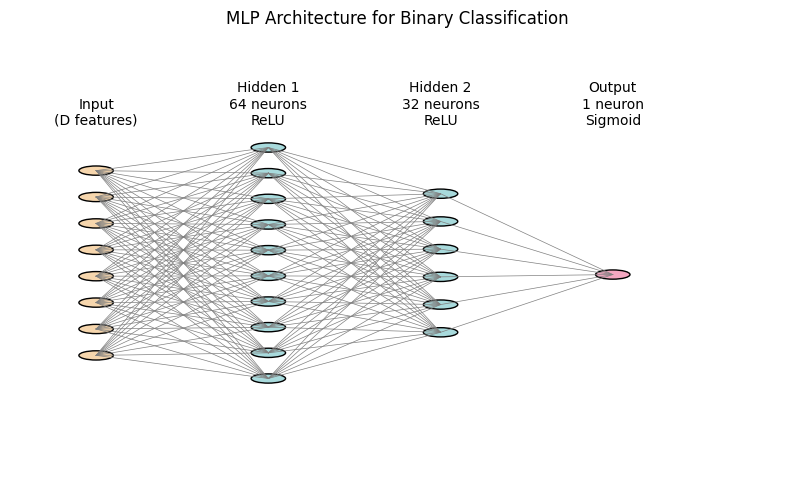

In [ ]:

def draw_mlp(input_neurons=8, hidden1=10, hidden2=6, output_neurons=1):
    """
    Draws a visual representation of an MLP.
    NOTE:
    We visually compress neurons for clarity.
    It does NOT draw all 64/32 neurons literally.
    """

    layer_sizes = [input_neurons, hidden1, hidden2, output_neurons]
    colors = ["#F6D6AD", "#A8DADC", "#A8DADC", "#F4A7C1"]  # pastel colors
    
    fig, ax = plt.subplots(figsize=(10,6))
    
    x_spacing = 2
    y_spacing = 1
    
    for layer_index, layer_size in enumerate(layer_sizes):
        x = layer_index * x_spacing
        y_positions = np.linspace(
            -layer_size / 2,
            layer_size / 2,
            layer_size
        )
        
        for y in y_positions:
            circle = plt.Circle((x, y), 0.2, color=colors[layer_index], ec="black")
            ax.add_patch(circle)
        
        # Draw connections to next layer
        if layer_index < len(layer_sizes) - 1:
            next_layer_size = layer_sizes[layer_index + 1]
            next_y_positions = np.linspace(
                -next_layer_size / 2,
                next_layer_size / 2,
                next_layer_size
            )
            
            for y1 in y_positions:
                for y2 in next_y_positions:
                    ax.plot(
                        [x, x + x_spacing],
                        [y1, y2],
                        color="gray",
                        linewidth=0.5
                    )

    # Labels
    layer_names = ["Input\n(D features)", 
                   "Hidden 1\n64 neurons\nReLU", 
                   "Hidden 2\n32 neurons\nReLU", 
                   "Output\n1 neuron\nSigmoid"]

    for i, name in enumerate(layer_names):
        ax.text(i * x_spacing, max(layer_sizes)/2 + 1,
                name,
                ha='center')

    ax.set_xlim(-1, x_spacing * (len(layer_sizes)))
    ax.set_ylim(-max(layer_sizes), max(layer_sizes))
    ax.axis("off")
    plt.title("MLP Architecture for Binary Classification")
    plt.show()


draw_mlp()

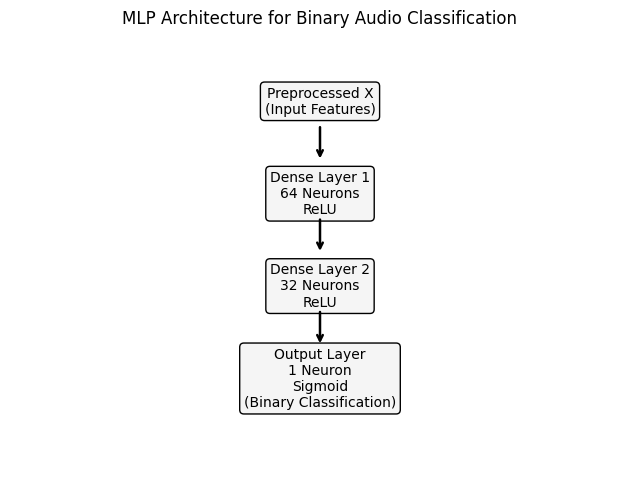

In [ ]:


def draw_mlp_flow_correct():
    fig, ax = plt.subplots(figsize=(8,6))

    box_style = dict(
        boxstyle="round",
        edgecolor="black",
        facecolor="#F5F5F5"
    )

    # Positions (top to bottom)
    input_pos   = (0.5, 0.85)
    dense1_pos  = (0.5, 0.65)
    dense2_pos  = (0.5, 0.45)
    output_pos  = (0.5, 0.25)

    # Draw boxes first
    ax.text(*input_pos,
            "Preprocessed X\n(Input Features)",
            ha="center", va="center", bbox=box_style)

    ax.text(*dense1_pos,
            "Dense Layer 1\n64 Neurons\nReLU",
            ha="center", va="center", bbox=box_style)

    ax.text(*dense2_pos,
            "Dense Layer 2\n32 Neurons\nReLU",
            ha="center", va="center", bbox=box_style)

    ax.text(*output_pos,
            "Output Layer\n1 Neuron\nSigmoid\n(Binary Classification)",
            ha="center", va="center", bbox=box_style)

    
    arrow_style = dict(arrowstyle="->", linewidth=1.8)

    ax.annotate("", xy=(0.5, 0.72), xytext=(0.5, 0.80), arrowprops=arrow_style)
    ax.annotate("", xy=(0.5, 0.52), xytext=(0.5, 0.60), arrowprops=arrow_style)
    ax.annotate("", xy=(0.5, 0.32), xytext=(0.5, 0.40), arrowprops=arrow_style)

    ax.set_xlim(0,1)
    ax.set_ylim(0,1)
    ax.axis("off")

    plt.title("MLP Architecture for Binary Audio Classification")
    plt.show()

draw_mlp_flow_correct()